In [1]:
import pandas
import os

df = pandas.read_csv(os.path.join('eval_result', 'summary.csv'), sep=';')

In [2]:
# df.fillna(0.5, inplace=True)
df

,MODEL,TC1,TC2,TC3,TC4,TC5,TC6,TC7,TC8,TC9,TC10,TC11,TC12,TC13,TC14
0,qwen:1.8b,0.20,0.50,0.2,0.10,1,?,0.326,0.2,?,0.90,?,0.90,0.00,0.00
1,qwen:4b,0.80,0.80,0.5,1.00,?,?,1.000,1.0,?,1.00,?,1.00,1.00,0.00
2,qwen2.5:0.5b,1.00,0.80,0.9,0.80,0.7,?,0.200,0.8,?,0.00,?,1.00,0.80,0.80
3,qwen2.5:1.5b,1.00,0.38,1.0,1.00,0.9,?,1.000,1.0,?,0.00,0.7,1.00,1.00,1.00
4,qwen2.5:3b,0.90,0.80,0.9,1.00,0.9625,?,1.000,0.8,?,1.00,1,1.00,1.00,0.50
5,qwen2.5-coder:1.5b,0.80,1.00,0.9,0.90,0.8,?,0.400,0.7,?,1.00,0.9,1.00,1.00,1.00
6,llama3.2:3b,0.95,0.80,0.5,1.00,0.9,?,1.000,1.0,?,0.95,1,1.00,0.90,0.90
7,mistral:7b,1.00,1.00,0.8,1.00,1,?,0.200,0.8,?,1.00,1,1.00,0.60,0.80
8,mistrallite:7b,1.00,0.60,1.0,0.90,0.9,?,1.000,1.0,?,1.00,1,1.00,1.00,0.70
9,codegemma:2b,0.00,0.80,0.9,0.80,?,?,0.600,0.5,?,0.00,0.5,1.00,0.50,0.50


In [3]:
models = ['qwen:1.8b', 'qwen:4b', 'qwen2.5:0.5b', 'qwen2.5:1.5b',
       'qwen2.5:3b', 'qwen2.5-coder:1.5b', 'llama3.2:3b', 'codegemma:2b', 'gemma2:2b', 'deepseek-r1:1.5b']

In [4]:
import math

def is_float(value):
    try:
        float(value)
        # if (math.isnan(float(value))):
        #     return False
        return True
    except ValueError:
        return False

def sum_eval(eval: list[float]):
    sum = 0
    for x in eval:
        if is_float(x):
            sum += float(x)
    return sum

def get_result(models: list[str]):
    avg_list = []
    for model in models:
        df_model = df[df['MODEL'] == model]
        del df_model['MODEL']
        eval = df_model.values[0]
        eval = [float(x) for x in eval if is_float(x)]
        # print(eval)
        # print(model, eval)
        avg_list.append((model, (sum_eval(eval) / len(eval))))
    return avg_list
    
# print(avg_list)
# for x in avg_list:
#     print(x)

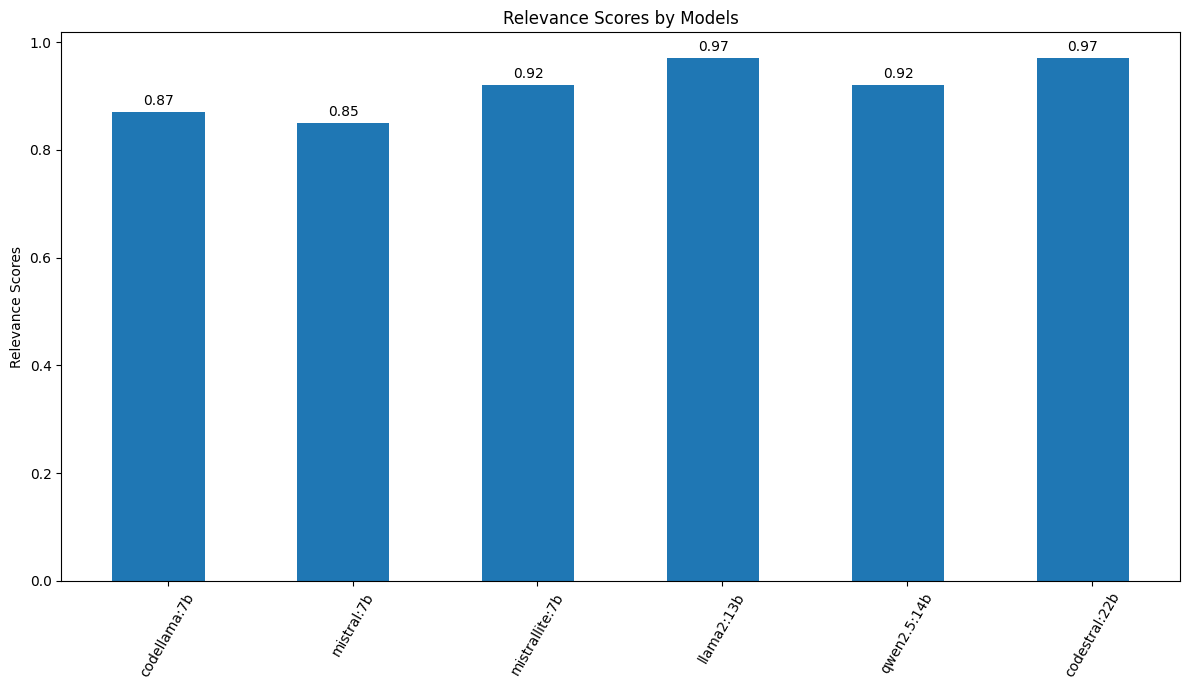

In [13]:
# Plot the result on a bar chart, each model has different color

import matplotlib.pyplot as plt
import numpy as np

avg_list = get_result(models)
labels = [x[0] for x in avg_list]
values = [x[1] for x in avg_list]

x = np.arange(len(labels))  # the label locations
width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 7))
rects = ax.bar(x - width/2, np.array(values, dtype=np.float32).round(2), width*5, label='Scores')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Relevance Scores')
ax.set_title('Relevance Scores by Models')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60)
# ax.legend()

ax.bar_label(rects, padding=3)

fig.tight_layout()

plt.show()

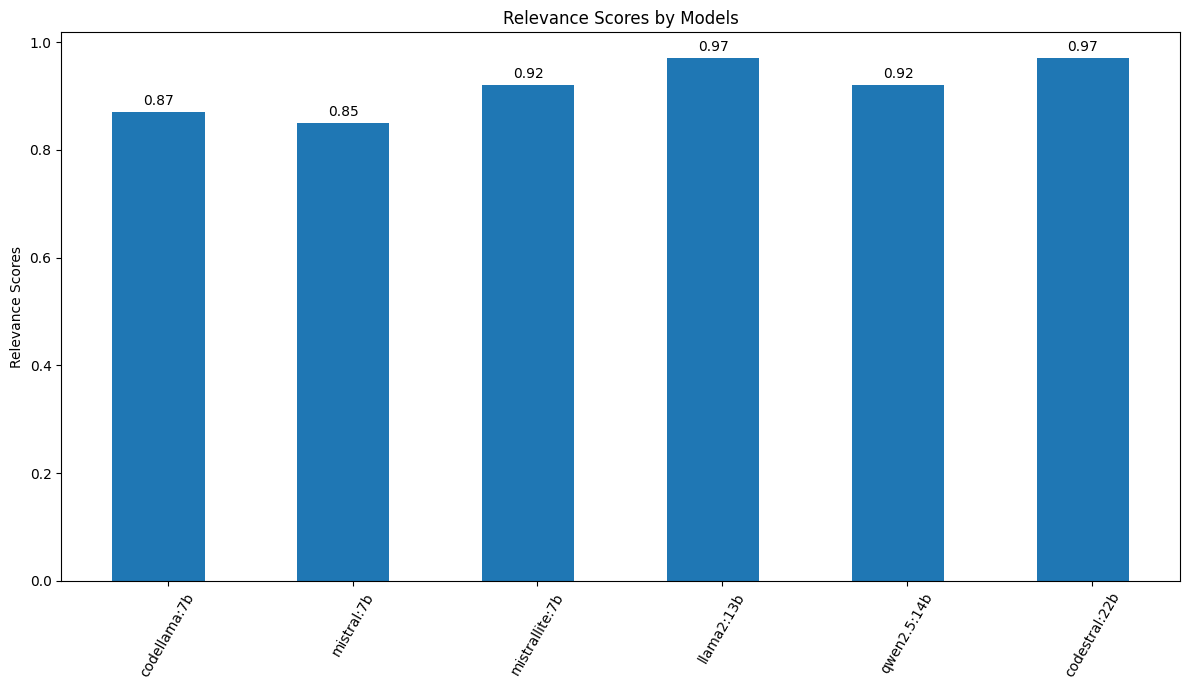

In [14]:
# Plot the result on a bar chart, each model has different color

import matplotlib.pyplot as plt
import numpy as np

models = ['codellama:7b', 'mistral:7b', 'mistrallite:7b', 'llama2:13b', 'qwen2.5:14b', 'codestral:22b']
avg_list = get_result(models)
labels = [x[0] for x in avg_list]
values = [x[1] for x in avg_list]

x = np.arange(len(labels))  # the label locations
width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 7))
rects = ax.bar(x - width/2, np.array(values, dtype=np.float32).round(2), width*5, label='Scores')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Relevance Scores')
ax.set_title('Relevance Scores by Models')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60)
# ax.legend()

ax.bar_label(rects, padding=3)

fig.tight_layout()

plt.show()